In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from Pruning import *
from scipy.linalg import solve, qr
import numpy as np
from Plot import *
import random
from model import *

# Transform to tensor
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

train_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

Files already downloaded and verified


/Users/yuekai/miniconda3/envs/CSSP_NN_Pruning/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


In [43]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
#device = torch.device("cpu")

model3 = VGG16().to(device)

loss_fun = nn.CrossEntropyLoss()
optimizer = optim.SGD(model3.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[100, 150], gamma=0.1
)

epoch = 200
best_acc = 0.0

for i in range(epoch):
    model3.train()
    train_correct = 0
    train_loss = 0

    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        outputs = model3(imgs)
        loss = loss_fun(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == targets).sum().item()

    model3.eval()
    test_correct = 0
    test_loss = 0

    with torch.no_grad():
        for imgs, targets in test_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)

            outputs = model3(imgs)
            loss = loss_fun(outputs, targets)

            test_loss += loss.item() * imgs.size(0)
            test_correct += (outputs.argmax(1) == targets).sum().item()

    scheduler.step()

    avg_train_loss = train_loss / len(train_data)
    avg_train_acc = train_correct / len(train_data)
    avg_test_loss = test_loss / len(test_data)
    avg_test_acc = test_correct / len(test_data)

    # save the best model
    if avg_test_acc > best_acc:
        best_acc = avg_test_acc
        torch.save(model3.state_dict(), "best_vgg16_cifar10.pth")
        print(f"Saved best model at epoch {i+1}, best test acc = {best_acc:.4f}")

    if i % 10 == 0:
        print(f"-------Epoch {i+1}-------")
        print(f"Train loss: {avg_train_loss:.4f}")
        print(f"Train acc: {avg_train_acc:.4f}")
        print(f"Test loss: {avg_test_loss:.4f}")
        print(f"Test acc: {avg_test_acc:.4f}")

print(f"Training finished. Best test acc: {best_acc:.4f}")

Saved best model at epoch 1, best test acc = 0.3205
-------Epoch 1-------
Train loss: 2.0524
Train acc: 0.2329
Test loss: 1.7615
Test acc: 0.3205
Saved best model at epoch 2, best test acc = 0.4405
Saved best model at epoch 3, best test acc = 0.4943
Saved best model at epoch 4, best test acc = 0.5252
Saved best model at epoch 5, best test acc = 0.5773
Saved best model at epoch 6, best test acc = 0.6306
Saved best model at epoch 7, best test acc = 0.6480
Saved best model at epoch 8, best test acc = 0.7251
Saved best model at epoch 10, best test acc = 0.7284
-------Epoch 11-------
Train loss: 0.6886
Train acc: 0.7802
Test loss: 1.1568
Test acc: 0.6364
Saved best model at epoch 13, best test acc = 0.7600
Saved best model at epoch 21, best test acc = 0.7885
-------Epoch 21-------
Train loss: 0.5776
Train acc: 0.8183
Test loss: 0.6795
Test acc: 0.7885
Saved best model at epoch 27, best test acc = 0.7904
-------Epoch 31-------
Train loss: 0.5381
Train acc: 0.8322
Test loss: 0.7089
Test acc: 

In [2]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
#device = torch.device("cpu")

model3 = VGG16().to(device)

# loss functiom & optimizer
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.SGD(model3.parameters(), lr=0.01)

epoch = 200

for i in range(epoch):
    # train
    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        outputs = model3(imgs)
        loss = loss_fun(outputs, targets)

        # optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # test
    total_test_loss = 0
    total_accuracy = 0
    wrong_indices = []
    base_idx = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            batch_size = targets.size(0)
            imgs = imgs.to(device)
            targets = targets.to(device)
            outputs = model3(imgs)

            loss0 = loss_fun(outputs, targets)
            total_test_loss = total_test_loss + loss0.item()

            accuracy = (outputs.argmax(1) == targets).sum().item()
            total_accuracy = total_accuracy + accuracy

            # Record indices of misclassified samples
            if i == epoch - 1:  # Only record for the last epoch
                wrong_in_batch = torch.where(outputs.argmax(1) != targets)[0]
                wrong_indices.extend((base_idx + wrong_in_batch).tolist())
                base_idx += batch_size

    if i % 10 == 0:            
        print("-------Epoch {}-------".format(i+1))
        print("Total loss in test set: {}".format(total_test_loss))
        print("Total accuracy in test set: {}".format(total_accuracy / len(test_data)))

print("Number of samples misclassified by the original model:", len(wrong_indices))

-------Epoch 1-------
Total loss in test set: 184.4105184674263
Total accuracy in test set: 0.5813
-------Epoch 11-------
Total loss in test set: 76.93647207319736
Total accuracy in test set: 0.8338
-------Epoch 21-------
Total loss in test set: 64.60297405719757
Total accuracy in test set: 0.8629
-------Epoch 31-------
Total loss in test set: 64.93798661977053
Total accuracy in test set: 0.8756
-------Epoch 41-------
Total loss in test set: 84.63007509708405
Total accuracy in test set: 0.8532
-------Epoch 51-------
Total loss in test set: 70.99254707247019
Total accuracy in test set: 0.8803
-------Epoch 61-------
Total loss in test set: 76.85768574476242
Total accuracy in test set: 0.8805
-------Epoch 71-------
Total loss in test set: 81.64989392459393
Total accuracy in test set: 0.8803
-------Epoch 81-------
Total loss in test set: 79.59097568690777
Total accuracy in test set: 0.8834
-------Epoch 91-------
Total loss in test set: 69.56581218540668
Total accuracy in test set: 0.8977
-

In [2]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
#device = torch.device("cpu")

model3 = VGG16().to(device)

# load the parameters
model3.load_state_dict(torch.load("model3.pth", map_location=device))

model3.to(device)
model3.eval()

/var/folders/7f/6p6cnlkn3qn5qj3ll8df4lsh0000gn/T/ipykernel_72209/4177369873.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model3.load_state_dict(torch.load("model3.pth

VGG16(
  (model): Sequential(
    (0): ConvBNReLU(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
    (1): ConvBNReLU(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): ConvBNReLU(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
    (4): ConvBNReLU(
      (block): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1

In [3]:
model3.eval()
batch_list = list(train_loader)
selected_batches = random.sample(batch_list, 8)  
X = torch.cat([batch[0] for batch in selected_batches], dim=0)
X = X.to(device)

In [4]:
total_accuracy, _ = evaluate_pruned_model(model3, test_loader)
print(total_accuracy)

0.9113


In [7]:
pruned_model_iter = iterative_pruning(model3, X, (3,32,32), 0.4, 0.95, "ARP")

acc, wrong_samples_pruned = evaluate_pruned_model(pruned_model_iter, test_loader)

print()
print(acc, len(wrong_samples_pruned))

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 486 -> 461

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 461 -> 437

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 437 -> 415

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 415 -> 394

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 394 -> 374

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 374 -> 355

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 355 -> 337

-------Begin pruning-------
layer_idx: 0, layer_type: ConvBNReLU
number of out_channels: 64 -> 60

-------Begin pruning-------
layer_idx: 0, layer_type: ConvBNReLU
number of out_channe

In [ ]:
# with bn_recalibration
import importlib
import Pruning

importlib.reload(Pruning)
pruned_model_iter = iterative_pruning(model3, X, (3,32,32), 0.4, 0.95, "ARP", train_loader)

acc, wrong_samples_pruned = evaluate_pruned_model(pruned_model_iter, test_loader)

print()
print(acc, len(wrong_samples_pruned))

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 486 -> 461

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 461 -> 437

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 437 -> 415

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 415 -> 394

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 394 -> 374

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 374 -> 355

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 355 -> 337

-------Begin pruning-------
layer_idx: 0, layer_type: ConvBNReLU
number of out_channels: 64 -> 60

-------Begin pruning-------
layer_idx: 0, layer_type: ConvBNReLU
number of out_channe

In [13]:
# with bn_recalibration
import importlib
import Pruning

importlib.reload(Pruning)
pruned_model_iter = iterative_pruning(model3, X, (3,32,32), 0.1, 0.95, "ARP", train_loader)

acc, wrong_samples_pruned = evaluate_pruned_model(pruned_model_iter, test_loader)

print()
print(acc, len(wrong_samples_pruned))

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 486 -> 461

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 461 -> 437

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 437 -> 415

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 415 -> 394

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 394 -> 374

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 374 -> 355

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 355 -> 337

-------Begin pruning-------
layer_idx: 0, layer_type: ConvBNReLU
number of out_channels: 64 -> 60

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_chann

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 486 -> 461

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 461 -> 437

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 437 -> 415

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 415 -> 394

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 394 -> 374

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 374 -> 355

-------Begin pruning-------
layer_idx: 0, layer_type: ConvBNReLU
number of out_channels: 64 -> 60

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 355 -> 337

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_chann

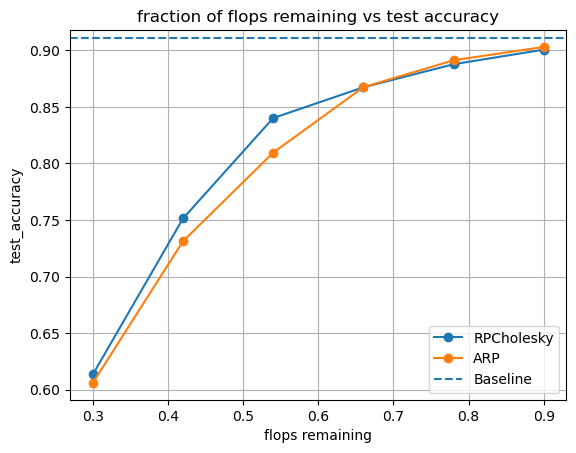

In [5]:
rho = np.linspace(0.3, 0.9, 6)
base_acc = total_accuracy
methods = ["RPCholesky", "ARP"]
all_accs = []
for method in methods:
    accs = []
    for r in rho:
        pruned_model_iter = iterative_pruning(model3, X, (3,32,32), r, 0.95, method)
        acc, _ = evaluate_pruned_model(pruned_model_iter, test_loader)
        accs.append(acc)
    all_accs.append(accs)

plot_pruning_curve(base_acc, rho, all_accs, methods,
                   title="fraction of flops remaining vs test accuracy")